# Stock Market Trend Analysis
### Predictive Analytics & Trading Signal Engine
Financial Services | Global Investment Partners

##### Organization Profile
Global Investment Partners manages
£500M across 10,000+ monthly trades
with sophisticated quant strategies. Yet
despite scale and expertise, systematic
underperformance persists.

##### The Problem
8% annual underperformance and
£3.5M in slippage losses signal
missed opportunities and inefficient
execution across market regimes.

##### Mission: 
Deploy data-driven market analysis and predictive modeling to enhance
trading performance and systematize decision-making.

### Day 1: Environment Setup & Data Loading
Objective: Set up the development environment and load all datasets successfully.

Tasks:

- Install required Python libraries: pandas, numpy, scikit-learn, matplotlib, seaborn

- Create project folder structure: /data, /notebooks, /models, /outputs

- Load all 5 CSV files into pandas DataFrames

- Verify data loading 

- Documentation


In [2]:
#Import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
#Import Datasets
company_info = pd.read_csv("company_info.csv")
market_indices = pd.read_csv("market_indices.csv")
stock_indicators = pd.read_csv("stock_prices_with_indicators.csv")
stock_prices =pd.read_csv("stock_prices.csv")

#### Data Inspection
data types, missing values, duplicates and time structure.

In [9]:
# Inspecting data types

datasets = {
    "company_info": company_info,
    "stock_prices": stock_prices,
    "stock_indicators": stock_indicators,
    "market_indices": market_indices
}

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print("Shape:", df.shape)
    print(df.info())
    print(df.head(3))



==== COMPANY_INFO ====
Shape: (20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        20 non-null     object
 1   company_name  20 non-null     object
 2   sector        20 non-null     object
 3   ipo_date      20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes
None
   ticker company_name      sector    ipo_date
0  STK001     TechCorp  Technology  2021-04-10
1  STK002  DataSystems  Technology  2016-10-12
2  STK003    CloudNine  Technology  2016-01-18

==== STOCK_PRICES ====
Shape: (15600, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          15600 non-null  object 
 1   date            15600 non-null  object 
 2   open            15600 non-null  fl

In [94]:
for name, df in datasets.items(): 

    print(f"\n===================== {name.upper()} ========================")
    
    print(df.describe())


===================== COMPANY_INFO ========================
                  ipo_date
count                   20
mean   2018-09-03 09:36:00
min    2016-01-18 00:00:00
25%    2016-09-08 06:00:00
50%    2017-10-28 12:00:00
75%    2020-12-17 00:00:00
max    2022-02-21 00:00:00

===================== STOCK_PRICES ========================
                      date          open          high           low  \
count                15600  15600.000000  15600.000000  15600.000000   
mean   2022-07-02 12:00:00    102.567353    104.372648    100.843603   
min    2021-01-04 00:00:00     21.060000     22.080000     21.060000   
25%    2021-10-03 06:00:00     63.350000     64.437500     62.245000   
50%    2022-07-02 12:00:00     88.630000     90.200000     87.245000   
75%    2023-03-31 18:00:00    131.302500    133.215000    129.002500   
max    2023-12-29 00:00:00    512.090000    517.100000    497.210000   
std                    NaN     58.873297     59.972069     57.872533   

             

### Documentation:

#### COMPANY_INFO
- Date is in object dtype

#### STOCK_PRICES
- Date is an object dtype, however should be in datetime dtype for time-series operations.
- Shape (15600, 8) vs indicators (15502, 31) means 98 rows missing in STOCK_INDICATORS. 

#### STOCK_INDICATORS
- Date is object
- Many columns Contain NaN
- Volume is a float64. Should be integer, this is to be consistent with STOCK_PRICES (where it’s int64).
- Row count (15502) - has Fewer rows than STOCK_PRICES (15600)

Convert date to datetime. Check if date frequency aligns with the stock data (likely fewer days, e.g., market holidays).

#### MARKET_INDICES
- Date is in object dtype.
- market_regime is Categorical, therefore, target variable to be done for modeling market conditions.

##### Solution: 
Convert all date variable to datetime

Handle missing values, duplicate values, outliers in the Stock Indicator Dataset

### Day 2: Data Quality Assessment
Objective: Understand the data quality and identify any issues that need addressing.

Tasks:

- Check for missing values in each dataset using .isnull().sum()

- Identify data type mismatches (e.g., dates stored as strings)

- Check for duplicate records

- Verify date ranges and continuity in time-series data

- Document data quality findings in a summary table


In [10]:
# Convert date columns
for df in [company_info, stock_prices, stock_indicators, market_indices]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

company_info['ipo_date'] = pd.to_datetime(company_info['ipo_date'])


In [13]:
# Recheck Dataframes :

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print("Shape:", df.shape)
    print(df.info())
    print(df.head(3))



==== COMPANY_INFO ====
Shape: (20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        20 non-null     object        
 1   company_name  20 non-null     object        
 2   sector        20 non-null     object        
 3   ipo_date      20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 772.0+ bytes
None
   ticker company_name      sector   ipo_date
0  STK001     TechCorp  Technology 2021-04-10
1  STK002  DataSystems  Technology 2016-10-12
2  STK003    CloudNine  Technology 2016-01-18

==== STOCK_PRICES ====
Shape: (15600, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15600 non-null  object        


In [11]:
# Check for ticker consistency
missing_tickers = set(stock_prices['ticker']) - set(company_info['ticker'])
print("Missing tickers in company_info:", missing_tickers)

Missing tickers in company_info: set()


In [18]:
 # Duplicates
for name, df in datasets.items():
    print("Duplicates:", df.duplicated().sum())

Duplicates: 0
Duplicates: 0
Duplicates: 0
Duplicates: 0


#### Checking for missing values

In [8]:
# Missing values in each dataset using .isnull().sum()

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print(df.isnull().sum())
   


==== COMPANY_INFO ====
ticker          0
company_name    0
sector          0
ipo_date        0
dtype: int64

==== STOCK_PRICES ====
ticker            0
date              0
open              0
high              0
low               0
close             0
volume            0
adjusted_close    0
dtype: int64

==== STOCK_INDICATORS ====
ticker                0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50   

In [20]:
# Calculate percentage of missing values
def missing_percentage(df):
    return (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

print("=== COMPANY_INFO Missing % ===")
print(missing_percentage(company_info), "\n")

print("=== STOCK_PRICES Missing % ===")
print(missing_percentage(stock_prices), "\n")

print("=== STOCK_INDICATORS Missing % ===")
print(missing_percentage(stock_indicators), "\n")

print("=== MARKET_INDICES Missing % ===")
print(missing_percentage(market_indices), "\n")


=== COMPANY_INFO Missing % ===
ticker          0.0
company_name    0.0
sector          0.0
ipo_date        0.0
dtype: float64 

=== STOCK_PRICES Missing % ===
ticker            0.0
date              0.0
open              0.0
high              0.0
low               0.0
close             0.0
volume            0.0
adjusted_close    0.0
dtype: float64 

=== STOCK_INDICATORS Missing % ===
momentum_20         2.580312
bb_width            2.135208
rsi_14              2.128758
macd                2.006193
volume_ratio        1.999742
sma_20              1.999742
momentum_10         1.290156
volatility_20       0.258031
bb_lower            0.129016
bb_upper            0.129016
price_to_sma_50     0.000000
bb_middle           0.000000
volume_sma_20       0.000000
atr_14              0.000000
true_range          0.000000
future_return_5d    0.000000
ticker              0.000000
macd_histogram      0.000000
date                0.000000
macd_signal         0.000000
ema_26              0.000000
ema_

In [50]:
# Check total and percentage of missing values for stock_indicators data:

missing_summary = stock_indicators.isna().sum().sort_values(ascending=False)
missing_percent = (stock_indicators.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    'Missing Values': missing_summary,
    'Percent Missing (%)': missing_percent
}).head(15)


,Missing Values,Percent Missing (%)
momentum_20,400,2.580312
bb_width,331,2.135208
rsi_14,330,2.128758
macd,311,2.006193
volume_ratio,310,1.999742
sma_20,310,1.999742
momentum_10,200,1.290156
volatility_20,40,0.258031
bb_lower,20,0.129016
bb_upper,20,0.129016


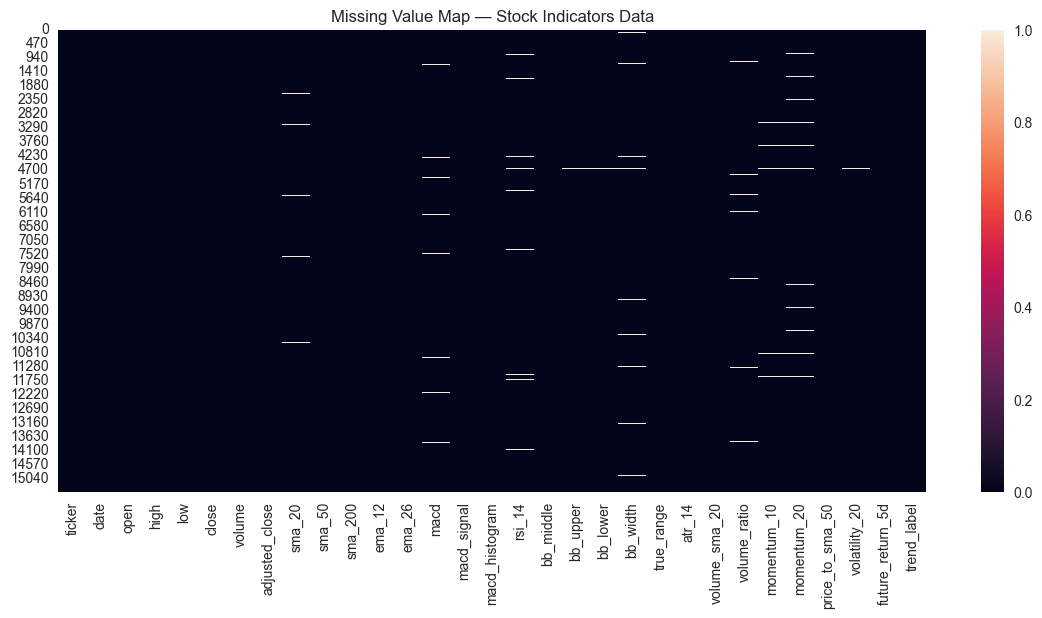

In [33]:
# Visualization of missing values in STOCK INDICATORS data

# Visualization settings
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)

# Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(stock_indicators.isna())
plt.title("Missing Value Map — Stock Indicators Data")
plt.show()

Image Observation:
- The sma_20, macd, rsi_14 lines in small chunks shows the use of Rolling window NaNs (each stock start)
- The volume_ratio, momentum_10, price_to_sma_50 are scattered across time. These features are likely missing due to merge mismatches or incomplete calculation for specific dates.
- the future_return_5d	missing at the end of each stock series is	normal, because  a 5-day future return cannot be computed for the last few rows.


Conclusion on missing value pattern:
- All missing values are exactly in the range (200–400 per feature), consistent with rolling window computations, not random scatter.
- The apparent “scatter” in the heatmap is because of the multiple tickers interleaved, so their early-window NaNs are spread vertically instead of clustered. Each ticker’s series starts at a different position in the full dataset.

#### Handling Missing values: 
- Although the missing values are typically <2% of total.
- However, forward filling values stategy will be beneficial for full continuity for ML training. This will fill short gaps smoothly (it is safe here because the rolling windows are purely derived features, not raw market data).

In [64]:
# Forward-fill for Modeling Continuity

stock_indicators_clean = stock_indicators.sort_values(['ticker', 'date']).groupby('ticker', group_keys=False).apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

In [66]:
# Recheck for missing values
stock_indicators_clean.isna().sum().sum()

0

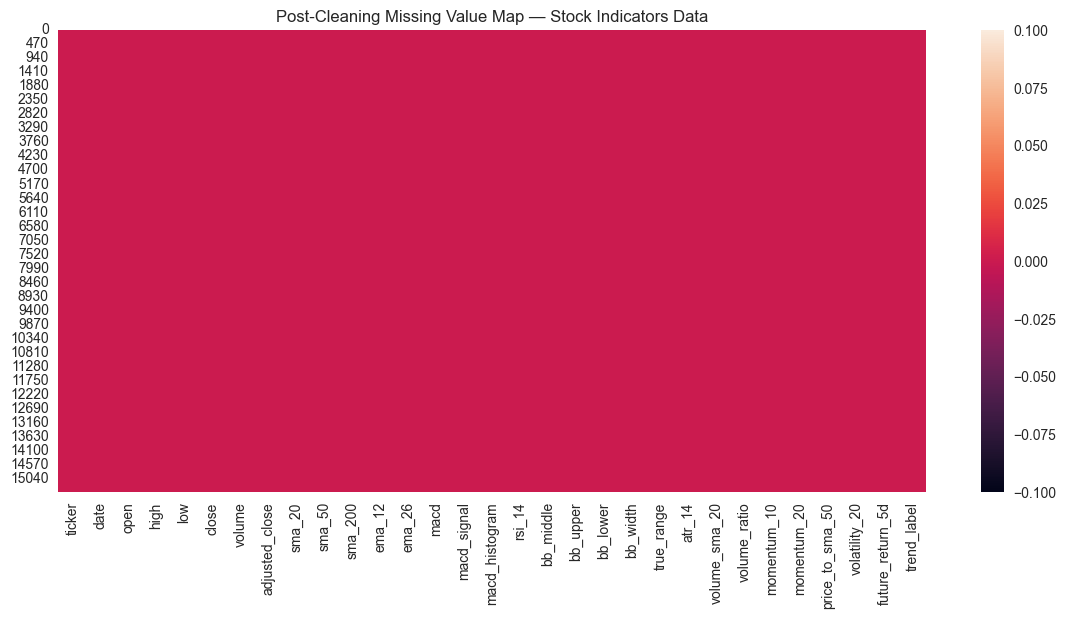

In [70]:
# Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(stock_indicators_clean.isna())
plt.title("Post-Cleaning Missing Value Map — Stock Indicators Data")
plt.show()

In [71]:
# Verify date ranges and continuity in time-series data

print("Company IPO date duration:", company_info['ipo_date'].min(), "→", company_info['ipo_date'].max())
print("Stock Prices date duration:", stock_prices['date'].min(), "→", stock_prices['date'].max())
print("Stock Indicator date duration:", stock_indicators['date'].min(), "→", stock_indicators['date'].max())
print("Market Indices date duration:", market_indices['date'].min(), "→", market_indices['date'].max())

Company IPO date duration: 2016-01-18 00:00:00 → 2022-02-21 00:00:00
Stock Prices date duration: 2021-01-04 00:00:00 → 2023-12-29 00:00:00
Stock Indicator date duration: 2021-01-04 00:00:00 → 2023-12-25 00:00:00
Market Indices date duration: 2021-01-04 00:00:00 → 2023-12-29 00:00:00


In [45]:
# Check for missing days in stock_prices

date_range = pd.date_range(stock_prices['date'].min(), stock_prices['date'].max())

missing_days = date_range.difference(stock_prices['date'].unique())

print("Missing trading days:", len(missing_days))


Missing trading days: 310


In [73]:
# Calculate coverage metrics per stock
date_coverage = (
    stock_prices.groupby('ticker')
    .agg(
        start_date=('date', 'min'), #The first available trading date for that ticker   
        end_date=('date', 'max'),  #The last available trading date
        total_days=('date', 'count'), #The number of trading records actually present  
        coverage_days=('date', lambda x: (x.max() - x.min()).days + 1),  #The span between first and last date (inclusive) 
        data_completeness=('date', lambda x: round((x.nunique() / ((x.max() - x.min()).days + 1)) * 100, 2))  #Percentage of days present out of the full possible date range
    )
    .reset_index()
)

# Add a new column showing period in years (optional)
date_coverage['coverage_years'] = round(date_coverage['coverage_days'] / 365, 2)

# Sort by start date (optional)
date_coverage = date_coverage.sort_values(by='start_date')

# Display result
date_coverage


,ticker,start_date,end_date,total_days,coverage_days,data_completeness,coverage_years
0,STK001,2021-01-04,2023-12-29,780,1090,71.56,2.99
17,STK018,2021-01-04,2023-12-29,780,1090,71.56,2.99
16,STK017,2021-01-04,2023-12-29,780,1090,71.56,2.99
15,STK016,2021-01-04,2023-12-29,780,1090,71.56,2.99
14,STK015,2021-01-04,2023-12-29,780,1090,71.56,2.99
13,STK014,2021-01-04,2023-12-29,780,1090,71.56,2.99
12,STK013,2021-01-04,2023-12-29,780,1090,71.56,2.99
11,STK012,2021-01-04,2023-12-29,780,1090,71.56,2.99
10,STK011,2021-01-04,2023-12-29,780,1090,71.56,2.99
9,STK010,2021-01-04,2023-12-29,780,1090,71.56,2.99


In [75]:
# Merge STOCK_PRICES and COMPANY_INFO
merged = stock_prices.merge(company_info[['ticker', 'ipo_date']], on='ticker', how='left')

# Group by ticker and compute adjusted coverage
coverage_ipo_aware = (
    merged.groupby('ticker')
    .agg(
        ipo_date=('ipo_date', 'first'),
        start_date=('date', 'min'),
        end_date=('date', 'max'),
        total_days=('date', 'count'),
        coverage_days=('date', lambda x: (x.max() - x.min()).days + 1)
    )
    .reset_index()
)

# Adjust the expected period: IPO → End date
coverage_ipo_aware['expected_days'] = (coverage_ipo_aware['end_date'] - coverage_ipo_aware['ipo_date']).dt.days + 1

# Clip negative values (for IPOs after end_date)
coverage_ipo_aware['expected_days'] = coverage_ipo_aware['expected_days'].clip(lower=1)

# Recalculate completeness
coverage_ipo_aware['data_completeness'] = (
    (coverage_ipo_aware['total_days'] / coverage_ipo_aware['expected_days']) * 100
).round(2)

coverage_ipo_aware['coverage_years'] = (coverage_ipo_aware['coverage_days'] / 365).round(2)

coverage_ipo_aware


,ticker,ipo_date,start_date,end_date,total_days,coverage_days,expected_days,data_completeness,coverage_years
0,STK001,2021-04-10,2021-01-04,2023-12-29,780,1090,994,78.47,2.99
1,STK002,2016-10-12,2021-01-04,2023-12-29,780,1090,2635,29.60,2.99
2,STK003,2016-01-18,2021-01-04,2023-12-29,780,1090,2903,26.87,2.99
3,STK004,2022-02-21,2021-01-04,2023-12-29,780,1090,677,115.21,2.99
4,STK005,2018-03-05,2021-01-04,2023-12-29,780,1090,2126,36.69,2.99
5,STK006,2017-12-01,2021-01-04,2023-12-29,780,1090,2220,35.14,2.99
6,STK007,2017-09-25,2021-01-04,2023-12-29,780,1090,2287,34.11,2.99
7,STK008,2017-01-08,2021-01-04,2023-12-29,780,1090,2547,30.62,2.99
8,STK009,2022-02-06,2021-01-04,2023-12-29,780,1090,692,112.72,2.99
9,STK010,2016-09-15,2021-01-04,2023-12-29,780,1090,2662,29.30,2.99


Findings: Majority of the Stock’s recorded trading started before its IPO — which, in real-world terms, should never happen.
A stock cannot have daily prices before it’s listed (i.e., before its IPO date).

This situation can be caused by one or more of the following:
- Synthetic / generated dataset:	Use of simulated or academic data, where IPO dates and stock dates might not have been synchronized.(Treat IPO dates as “metadata,” not literal limits. Adjust completeness based only on trading range.)
- Data extraction issue:	Some stock tables were truncated to a fixed range (e.g., 2021-01-04 → 2023-12-29) for all stocks.
- IPO date mis-formatting:	IPO dates might be stored as actual dates but meant to indicate “record inception” instead of “listing.”

In stock market data, not single calendar day is expect to appear because:

- Markets are closed on weekends and holidays.

- So typically, there are 250 trading days per year instead of 365.

The stock_prices data duration from Jan 2021 to Dec 2023 spans about 3 years, that’s roughly 3 * (365 - 250) = ~345 missing days — Therefore 310 days are reasonably missing.

### Day 3-4: Exploratory Data Analysis (EDA)
Objective: Understand price patterns, trends, and relationships in the data.
Analysis Tasks:

- #### Price Trend Analysis:
Plot closing prices for 5 different stocks (one from each sector).
Identify uptrends, downtrends, and sideways periods visually.
Calculate basic statistics: mean, median, std dev of returns.

- #### Sector Comparison:
Calculate average returns by sector.
Compare volatility across sectors.
Visualize sector performance with box plots.

- #### Volume Analysis:
Plot volume patterns over time.
Identify high-volume days and their relationship to price changes.
Calculate correlation between volume and price movement.

- #### Technical Indicator Exploration:
Visualize RSI patterns and identify overbought/oversold conditions.
Plot MACD crossovers and their relationship to price trends.
Examine Bollinger Band patterns.

- #### Correlation Analysis:
Create correlation heatmap of selected features.
Identify highly correlated features (potential multicollinearity).


In [99]:
# Pick one ticker per sector, (this ensures sector diversity for trend analysis.)

# Pick one ticker per sector 
sample_tickers = (
    company_info.groupby('sector')[['ticker']]
    .first()
    .reset_index()
)

# ...and label sample tickers with sector for more insight (Create a combined label e.g. "STK001 (Technology))

sample_tickers['ticker_label'] = (
    sample_tickers['ticker'] + " (" + sample_tickers['sector'] + ")"
)

# Convert to list of tuples for easy referencing later
ticker_pairs = list(zip(sample_tickers['ticker'], sample_tickers['ticker_label']))

sample_tickers

,sector,ticker,ticker_label
0,Consumer,STK013,STK013 (Consumer)
1,Energy,STK017,STK017 (Energy)
2,Finance,STK009,STK009 (Finance)
3,Healthcare,STK005,STK005 (Healthcare)
4,Technology,STK001,STK001 (Technology)


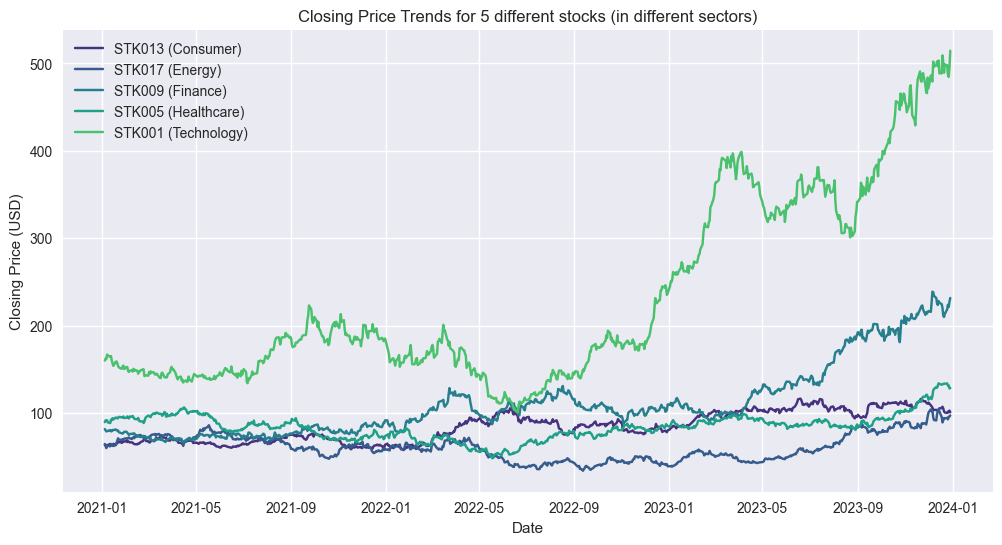

In [112]:
# Plot price trends

plt.figure(figsize=(12, 6))

for ticker, label in ticker_pairs:
    df_t = stock_prices[stock_prices['ticker'] == ticker]
    plt.plot(df_t['date'], df_t['close'], label=label)

plt.title("Closing Price Trends for 5 different stocks (in different sectors)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

##### Visual Interpretation:

- Uptrend: Stock STK001 sustained higher highs from mid 2022 till 2024 & higher lows.
- Downtrend: Stock STK013 Sustained lower highs since 2021 till 2024.
- Sideways: Stock Prices of Stock STK017,Stock STK009 and Stock STK00 fluctuate within a narrow range.

In [117]:
# Compute daily returns per ticker
stock_prices['daily_return'] = stock_prices.groupby('ticker')['close'].pct_change()

# Compute mean, median, and std dev (volatility) of returns
return_stats = (
    stock_prices.groupby('ticker')['daily_return']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_return', 'std': 'volatility'})
)

# Merge sector info
return_stats = return_stats.merge(company_info[['ticker', 'sector']], on='ticker', how='left')

# Format as percentage
return_stats[['mean_return', 'median', 'volatility']] = return_stats[['mean_return', 'median', 'volatility']] * 100

return_stats.head()

,ticker,mean_return,median,volatility,sector
0,STK001,0.179964,0.183127,2.451130,Technology
1,STK002,-0.045231,0.012486,2.531730,Technology
2,STK003,0.022435,0.026450,2.536600,Technology
3,STK004,0.034995,-0.010676,2.519444,Technology
4,STK005,0.069417,-0.011592,2.150682,Healthcare


In [122]:
#Print key insights dynamically:

top_vol = summary_df.loc[summary_df['volatility'].idxmax()]
top_stable = summary_df.loc[summary_df['volatility'].idxmin()]

print(f"{top_vol['ticker']} ({top_vol['sector']}) shows the highest volatility at {top_vol['volatility']:.2f}%, indicating larger daily price swings.")
print(f"{top_stable['ticker']} ({top_stable['sector']}) shows the lowest volatility at {top_stable['volatility']:.2f}%, suggesting more stable performance.")


STK017 (Energy) shows the highest volatility at 2.96%, indicating larger daily price swings.
STK013 (Consumer) shows the lowest volatility at 1.89%, suggesting more stable performance.


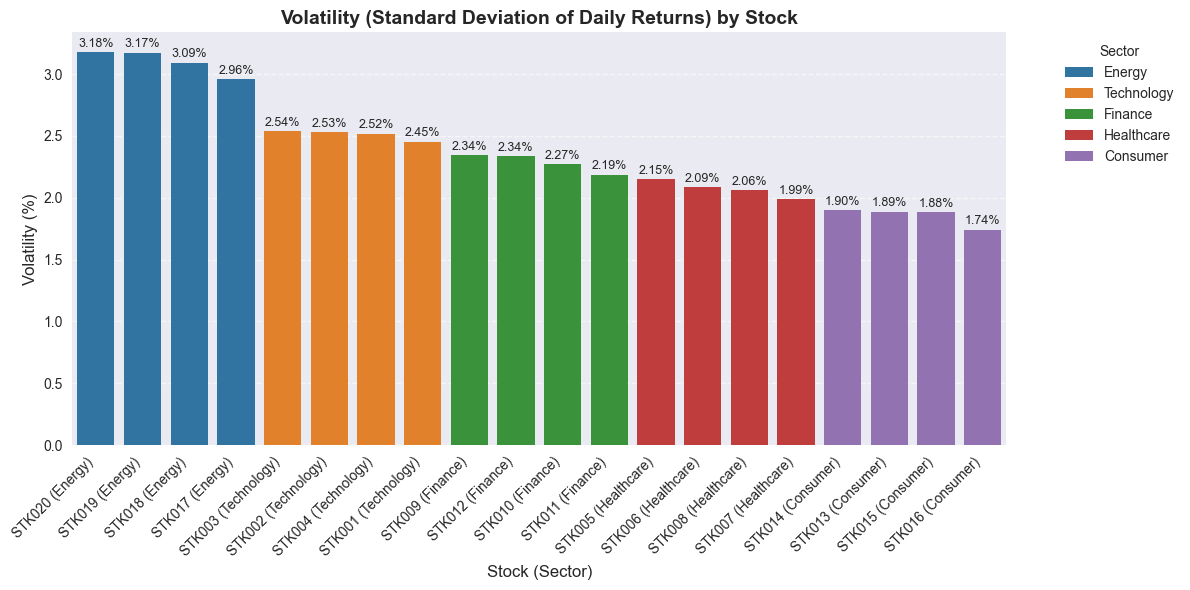

In [125]:
# Visualize Return Volatility per stock

# Ensure volatility is in percentage and column name matches
return_stats['Std Dev (%)'] = return_stats['volatility']

# Create a label combining ticker and sector
return_stats['Label'] = return_stats['ticker'] + " (" + return_stats['sector'] + ")"

# Sort by volatility for better readability
return_stats = return_stats.sort_values('Std Dev (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Label', 
    y='Std Dev (%)', 
    hue='sector', 
    data=return_stats, 
    dodge=False, 
    palette='tab10'
)

# Add text labels for each bar
for i, val in enumerate(return_stats['Std Dev (%)']):
    plt.text(i, val + 0.02, f"{val:.2f}%", ha='center', va='bottom', fontsize=9)

plt.title("Volatility (Standard Deviation of Daily Returns) by Stock", fontsize=14, fontweight='bold')
plt.xlabel("Stock (Sector)", fontsize=12)
plt.ylabel("Volatility (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### Interpretation:
- Higher Mean Return: Strong upward bias (possible uptrend).
- High Std Dev: More volatility; larger swings up/down.Median ≈ 0 = Indicates sideways movement or balance between gains/losses.

### Sector Comparison:

In [128]:
# --- Calculate daily returns from stock_prices ---
stock_prices['daily_return'] = stock_prices.groupby('ticker')['close'].pct_change()

stock_prices


,ticker,date,open,high,low,close,volume,adjusted_close,daily_return
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644,160.11,NaN
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36,0.014053
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177,161.78,-0.003572
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833,167.07,0.032699
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261,165.68,-0.008320
...,...,...,...,...,...,...,...,...,...
15595,STK020,2023-12-25,75.77,75.77,71.39,72.81,1189734,72.81,-0.052077
15596,STK020,2023-12-26,73.11,78.51,73.11,77.81,1358179,77.81,0.068672
15597,STK020,2023-12-27,78.74,78.74,76.32,76.89,1436557,76.89,-0.011824
15598,STK020,2023-12-28,74.46,75.85,73.62,75.10,1419570,75.10,-0.023280


In [131]:
# --- Merge stock_prices with company_info to get sector info ---
merged_df = pd.merge(
    stock_prices,
    company_info[['ticker', 'sector']],
    on='ticker',
    how='left'
)

# Drop missing or invalid return values
merged_df = merged_df.dropna(subset=['daily_return'])

merged_df

,ticker,date,open,high,low,close,volume,adjusted_close,daily_return,sector
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36,0.014053,Technology
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177,161.78,-0.003572,Technology
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833,167.07,0.032699,Technology
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261,165.68,-0.008320,Technology
5,STK001,2021-01-11,164.72,166.21,161.91,164.33,1132210,164.33,-0.008148,Technology
...,...,...,...,...,...,...,...,...,...,...
15595,STK020,2023-12-25,75.77,75.77,71.39,72.81,1189734,72.81,-0.052077,Energy
15596,STK020,2023-12-26,73.11,78.51,73.11,77.81,1358179,77.81,0.068672,Energy
15597,STK020,2023-12-27,78.74,78.74,76.32,76.89,1436557,76.89,-0.011824,Energy
15598,STK020,2023-12-28,74.46,75.85,73.62,75.10,1419570,75.10,-0.023280,Energy


In [134]:
# --- Compute average return and volatility (std dev) per sector ---
sector_stats = merged_df.groupby('sector')['daily_return'].agg(
    avg_return='mean',
    volatility='std'
).reset_index()

# Convert to percentage format for clarity
sector_stats['avg_return'] *= 100
sector_stats['volatility'] *= 100

print("Sector Summary Statistics:")
sector_stats.round(3)

Sector Summary Statistics:


,sector,avg_return,volatility
0,Consumer,0.055,1.853
1,Energy,0.035,3.101
2,Finance,0.075,2.284
3,Healthcare,0.044,2.072
4,Technology,0.048,2.510


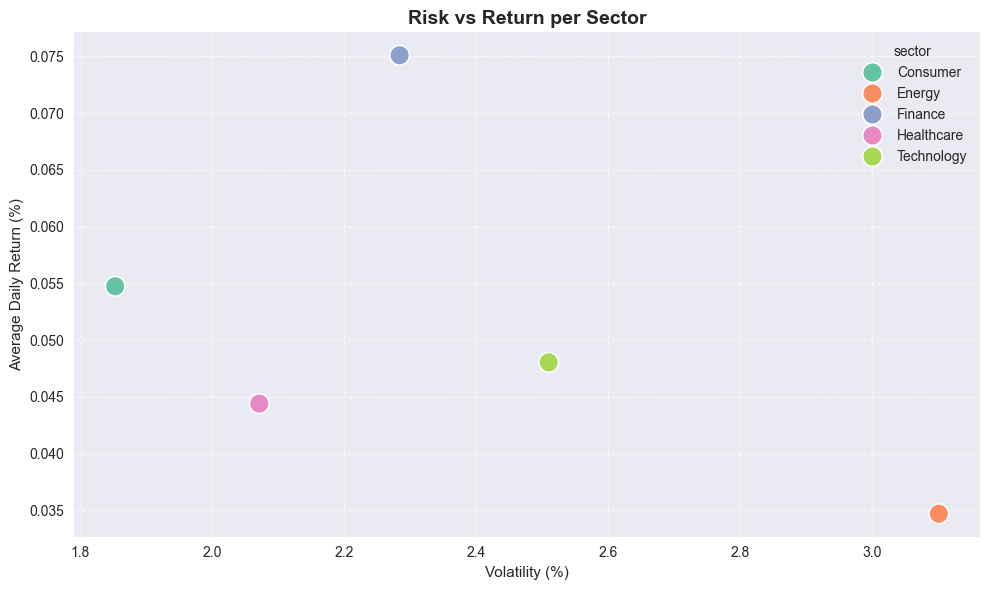

In [135]:
# --- Visualize average return vs volatility per sector (scatter) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sector_stats,
    x='volatility',
    y='avg_return',
    hue='sector',
    s=200,
    palette='Set2'
)
plt.title("Risk vs Return per Sector", fontsize=14, weight='bold')
plt.xlabel("Volatility (%)")
plt.ylabel("Average Daily Return (%)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/1429155438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='sector', y='daily_return', palette='Set3')


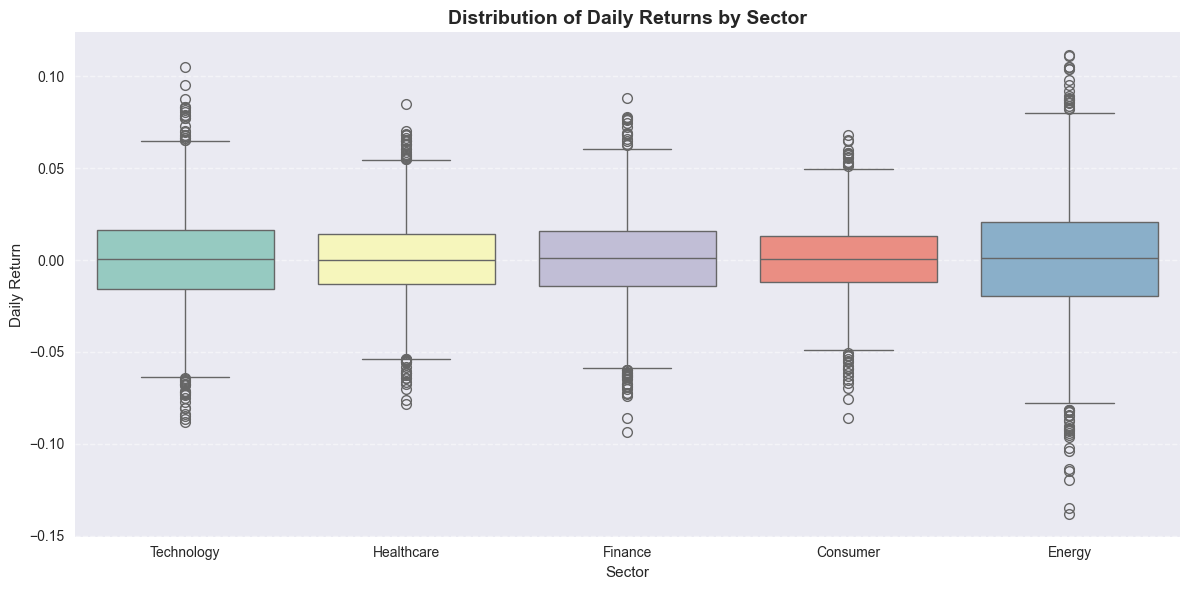

In [137]:
# --- Boxplot for return distribution by sector ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x='sector', y='daily_return', palette='Set3')
plt.title("Distribution of Daily Returns by Sector", fontsize=14, weight='bold')
plt.xlabel("Sector")
plt.ylabel("Daily Return")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend
plt.show()


The above boxplot image indicatates the prescence of outliers which shows a general high volatility trend in the stock market, this could indicate major events such as earnings etc.

### Volume Analysis:
- Plot volume patterns over time.
- Identify high-volume days and their relationship to price changes.
- Calculate correlation between volume and price movement

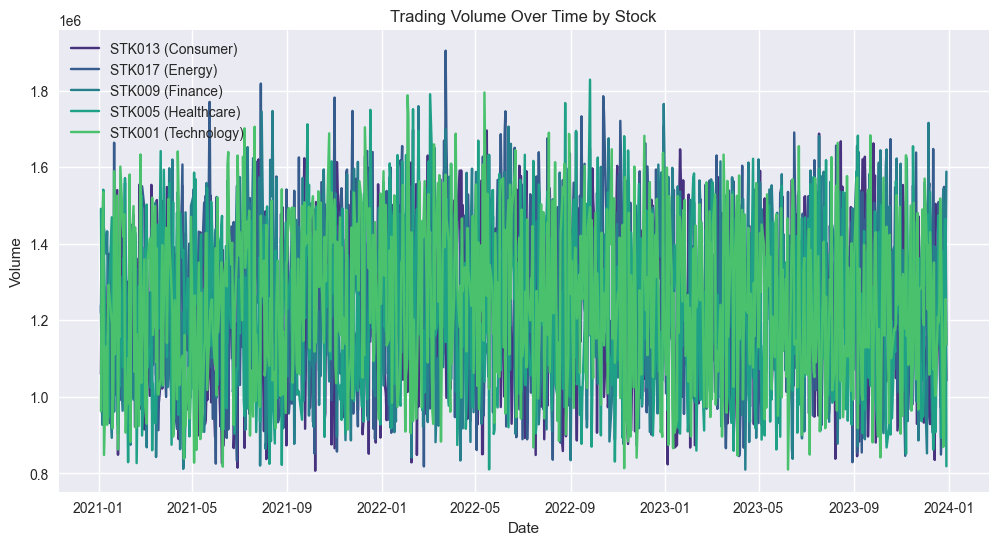

In [139]:
# Plot Volume Trends Over Time - Visualize how trading activity changes

# Choose a few representative tickers (e.g. one per sector)
sample_tickers = company_info.groupby('sector')['ticker'].first().tolist()

plt.figure(figsize=(12,6))
for t in sample_tickers:
    subset = stock_prices[stock_prices['ticker'] == t]
    plt.plot(subset['date'], subset['volume'], label=f"{t} ({company_info.loc[company_info['ticker']==t, 'sector'].values[0]})")

plt.title("Trading Volume Over Time by Stock")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.show()


##### Interpretation:

Peaks indicate high trading activity (possibly due to earnings announcements, news, or major price swings).

Consistent patterns suggest steady investor engagement.

In [143]:
# Identify High-Volume Days and Their Price Impact

# Compute daily return (%)
stock_prices['daily_return'] = stock_prices.groupby('ticker')['close'].pct_change()

# Define high volume as > 90th percentile per stock
stock_prices['high_volume'] = stock_prices.groupby('ticker')['volume'].transform(
    lambda x: x > x.quantile(0.9)
)

# Examine price changes on high-volume days
high_volume_summary = stock_prices.groupby('high_volume')['daily_return'].agg(['mean', 'std', 'count'])

high_volume_summary


,mean,std,count
high_volume,,,
False,0.000491,0.021754,14021
True,0.000717,0.038890,1559


##### Interpretation:

If mean return is significantly higher on high-volume days, it suggests momentum buying or selling.

If volatility (std) is higher, these are event-driven trading days.

/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/1788061474.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=correlations, x='sector', y='corr_volume_return', palette='Set2')


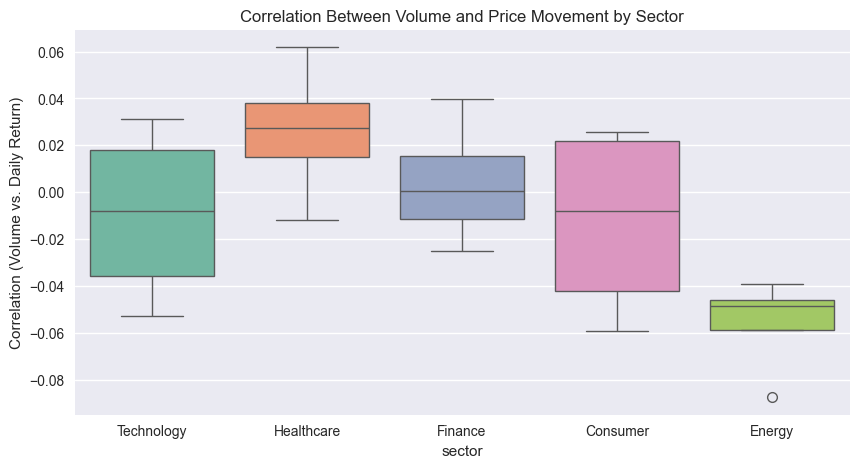

In [144]:
# Correlation Between Volume and Price Movement

# Compute correlation per stock
correlations = (
    stock_prices.groupby('ticker')
    .apply(lambda x: x['volume'].corr(x['daily_return']))
    .reset_index(name='corr_volume_return')
)

# Merge with sector info
correlations = correlations.merge(company_info[['ticker', 'sector']], on='ticker', how='left')

# Visualize correlation by sector
plt.figure(figsize=(10,5))
sns.boxplot(data=correlations, x='sector', y='corr_volume_return', palette='Set2')
plt.title("Correlation Between Volume and Price Movement by Sector")
plt.ylabel("Correlation (Volume vs. Daily Return)")
plt.show()


##### Interpretation:

Positive correlation → Price rises with higher volume (bullish sentiment).

Negative correlation → Heavy selling during declines.

Near zero → No consistent volume-price relationship.

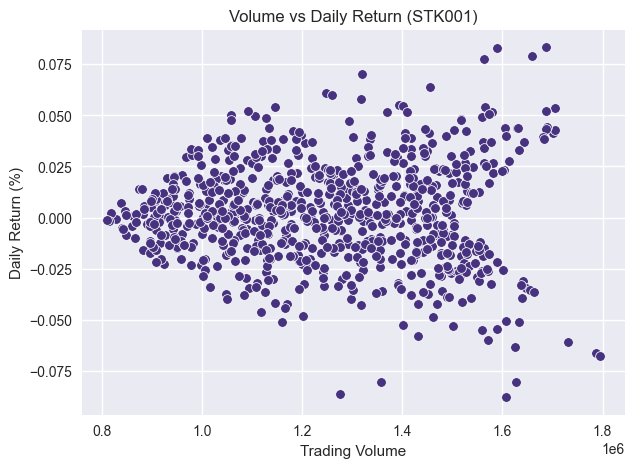

In [171]:
# simple scatter plot to visualize this relationship for one stock:

sample_ticker = 'STK001'
subset = stock_prices[stock_prices['ticker'] == sample_ticker]

plt.figure(figsize=(7,5))
sns.scatterplot(x='volume', y='daily_return', data=subset)
plt.title(f"Volume vs Daily Return ({sample_ticker})")
plt.xlabel("Trading Volume")
plt.ylabel("Daily Return (%)")
plt.show()

In [168]:
# Filter a Single Stock - to  analyze one ticker at a time:

ticker = "STK001"
df = stock_indicators[stock_indicators["ticker"] == ticker].copy()
df = df.sort_values("date")

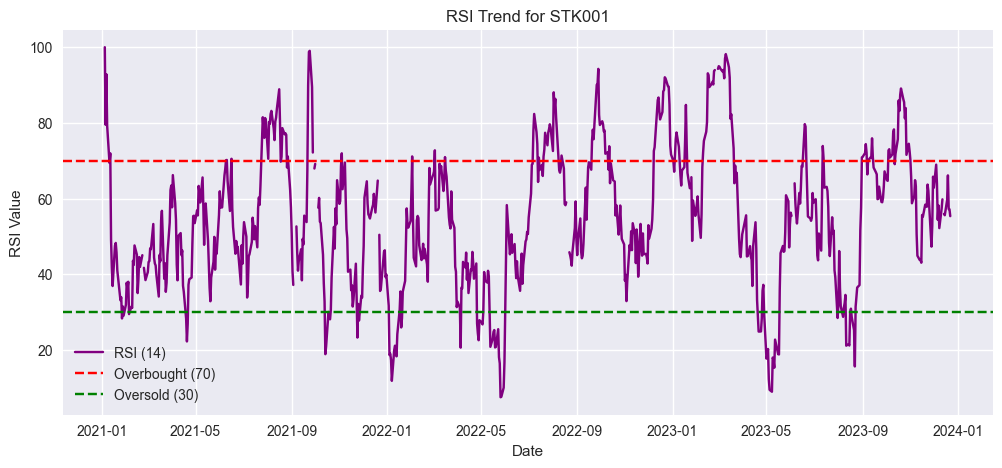

In [169]:
# RSI (Relative Strength Index) — Overbought / Oversold

# RSI > 70 → Overbought
# RSI < 30 → Oversold

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["rsi_14"], label="RSI (14)", color="purple")
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title(f"RSI Trend for {ticker}")
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend()
plt.grid(True)
plt.show()

##### Interpretation:

Peaks above 70 → Potential price pullback

Dips below 30 → Possible buying opportunity

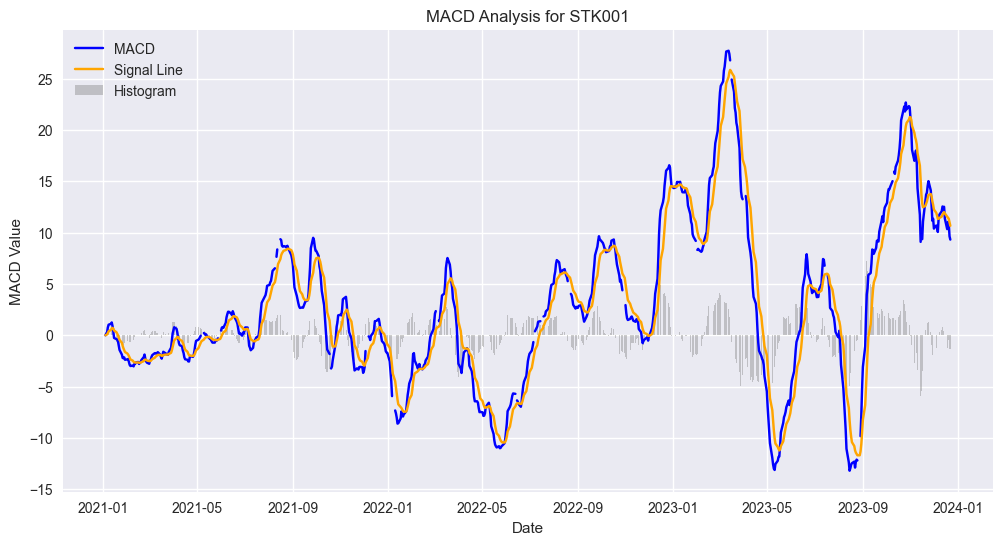

In [172]:
# MACD (Moving Average Convergence Divergence) - MACD crossovers help identify trend direction shifts.

plt.figure(figsize=(12,6))
plt.plot(df["date"], df["macd"], label="MACD", color="blue")
plt.plot(df["date"], df["macd_signal"], label="Signal Line", color="orange")
plt.bar(df["date"], df["macd_histogram"], label="Histogram", color="grey", alpha=0.4)
plt.title(f"MACD Analysis for {ticker}")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.legend()
plt.grid(True)
plt.show()

##### Interpretation:

When MACD crosses above Signal → Bullish momentum

When MACD crosses below Signal → Bearish shift

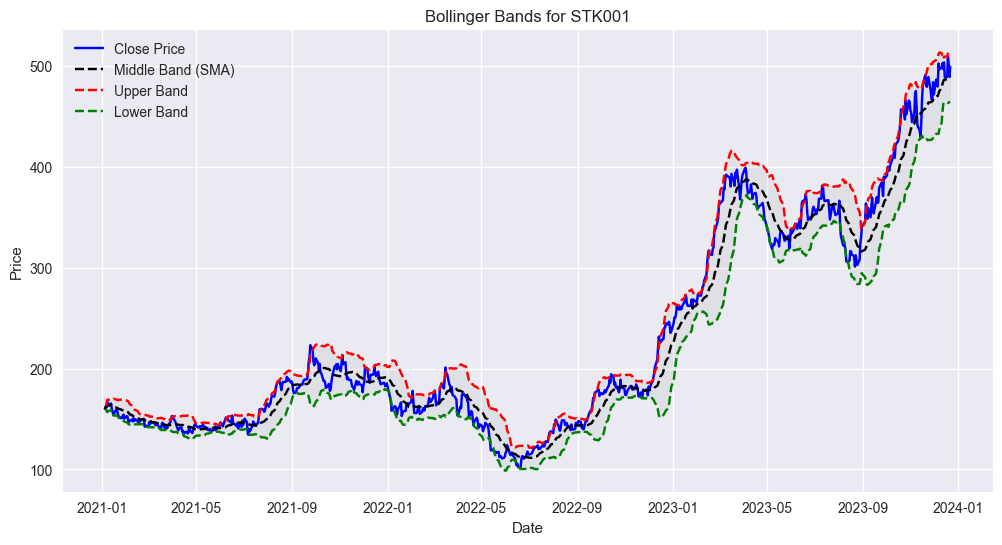

In [173]:
# Bollinger Bands — Price Volatility Patterns (These bands show price volatility and potential breakout zones.)

plt.figure(figsize=(12,6))
plt.plot(df["date"], df["close"], label="Close Price", color="blue")
plt.plot(df["date"], df["bb_middle"], label="Middle Band (SMA)", color="black", linestyle="--")
plt.plot(df["date"], df["bb_upper"], label="Upper Band", color="red", linestyle="--")
plt.plot(df["date"], df["bb_lower"], label="Lower Band", color="green", linestyle="--")
plt.fill_between(df["date"], df["bb_lower"], df["bb_upper"], color='grey', alpha=0.1)
plt.title(f"Bollinger Bands for {ticker}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

##### Interpretation:

When price touches upper band, it may be overbought

When price touches lower band, it may be oversold

When bands widen, volatility increases

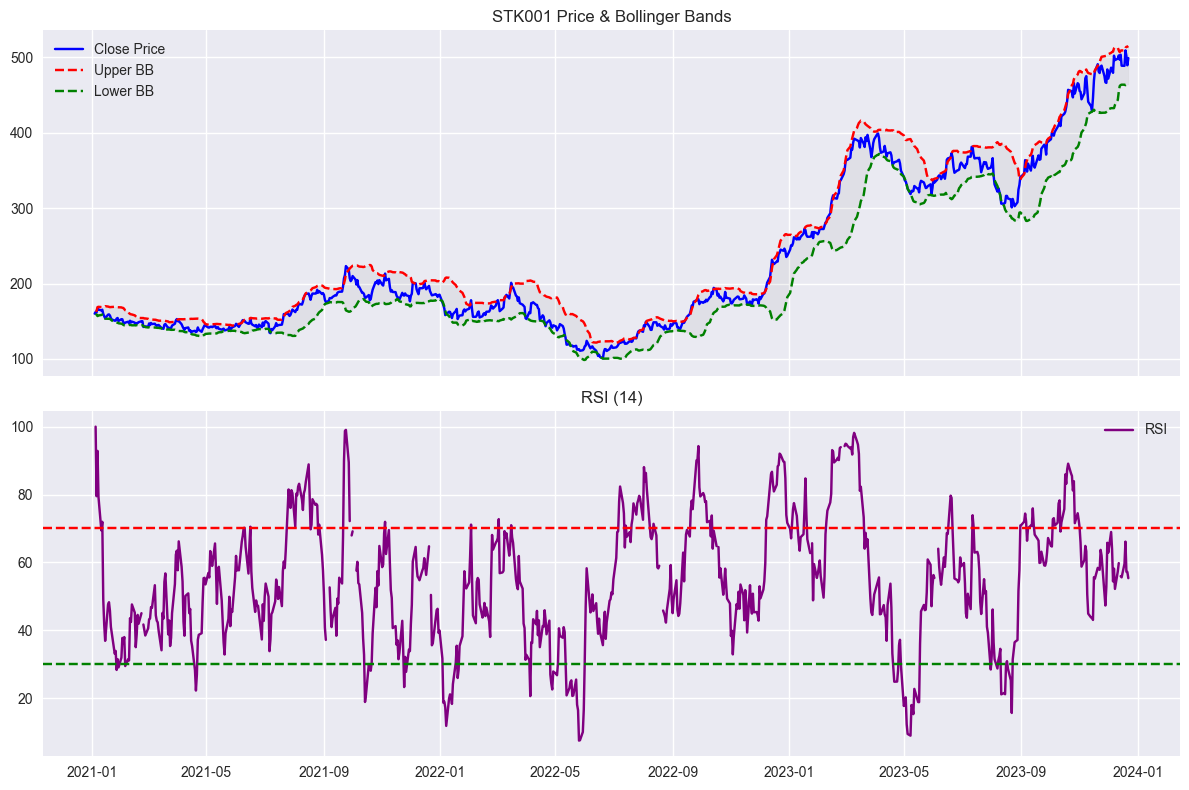

In [174]:
# Combine Price & MACD or RSI in a Single Figure - To correlate indicator signals with price trends:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Price and Bollinger Bands
ax1.plot(df["date"], df["close"], label="Close Price", color="blue")
ax1.plot(df["date"], df["bb_upper"], label="Upper BB", color="red", linestyle="--")
ax1.plot(df["date"], df["bb_lower"], label="Lower BB", color="green", linestyle="--")
ax1.fill_between(df["date"], df["bb_lower"], df["bb_upper"], color='grey', alpha=0.1)
ax1.set_title(f"{ticker} Price & Bollinger Bands")
ax1.legend()

# RSI
ax2.plot(df["date"], df["rsi_14"], label="RSI", color="purple")
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_title("RSI (14)")
ax2.legend()

plt.tight_layout()
plt.show()

RSI	Detects momentum strength	Above 70 = Overbought, Below 30 = Oversold. 
 MACD	Tracks trend direction	Crossovers indicate shifts
. Bollinger Bands	Measures volatility	Price touching bands = extreme conditions

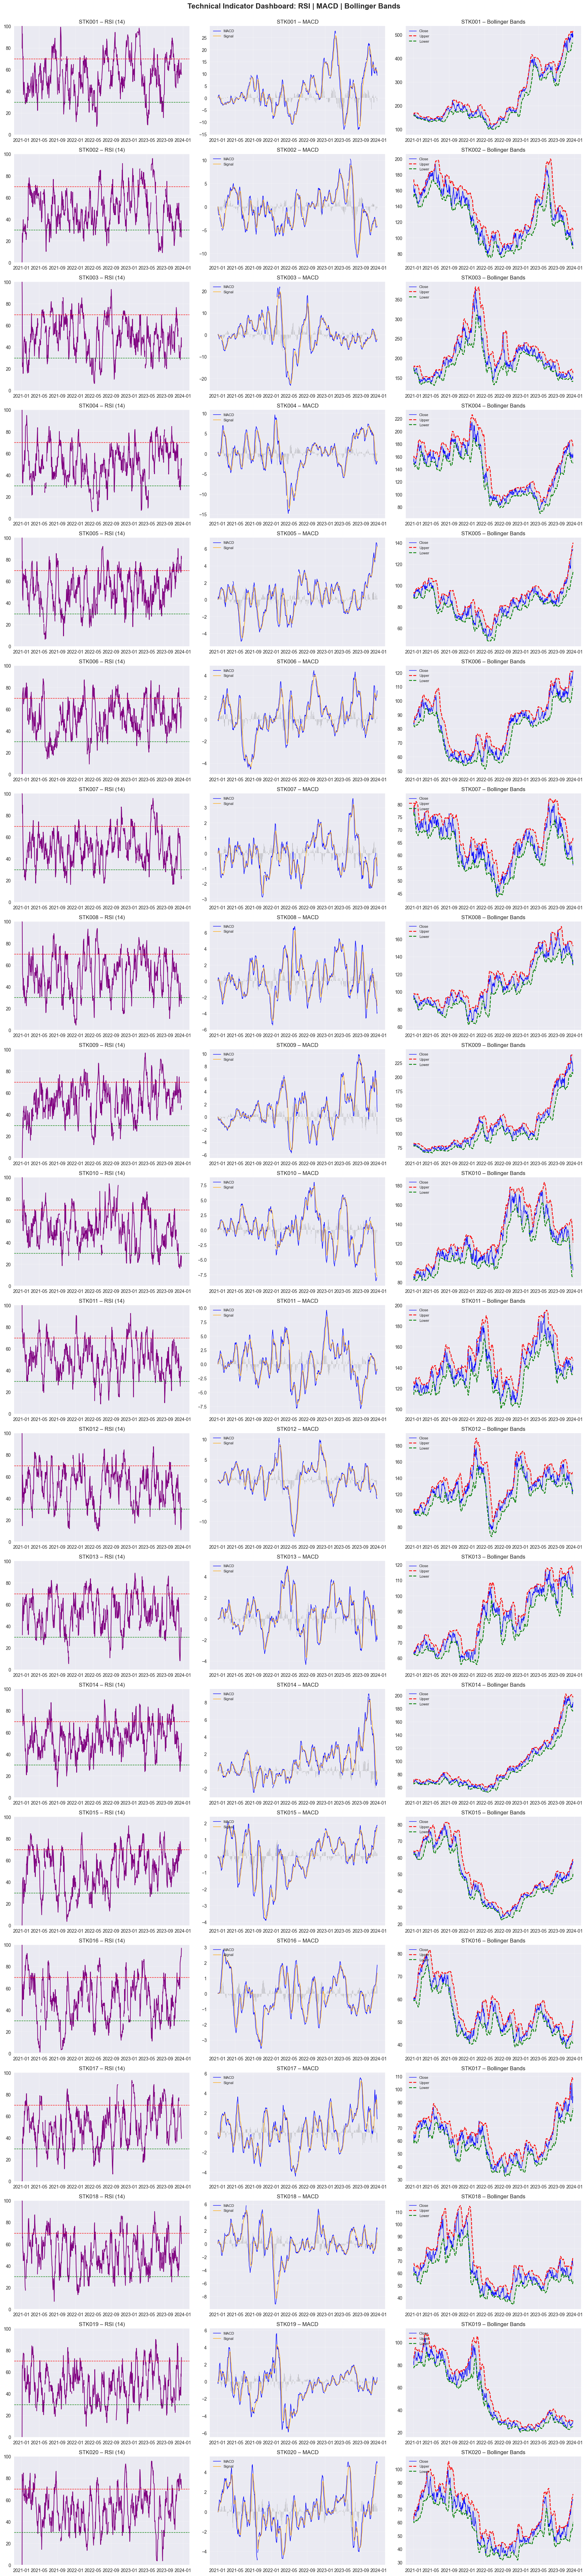

In [175]:
# Full Technical Indicator Dashboard (All 20 Tickers)

# Get the list of tickers
tickers = company_info["ticker"].unique()

# Set up the figure
fig, axes = plt.subplots(len(tickers), 3, figsize=(18, len(tickers)*4))
fig.suptitle("Technical Indicator Dashboard: RSI | MACD | Bollinger Bands", fontsize=16, weight='bold')

# Loop through each ticker
for i, ticker in enumerate(tickers):
    df = stock_indicators[stock_indicators["ticker"] == ticker].sort_values("date").copy()

    # --- RSI (Left Column)
    ax1 = axes[i, 0]
    ax1.plot(df["date"], df["rsi_14"], color="purple", linewidth=1.5)
    ax1.axhline(70, color='red', linestyle='--', linewidth=1)
    ax1.axhline(30, color='green', linestyle='--', linewidth=1)
    ax1.set_title(f"{ticker} – RSI (14)")
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3)

    # --- MACD (Middle Column)
    ax2 = axes[i, 1]
    ax2.plot(df["date"], df["macd"], label="MACD", color="blue", linewidth=1)
    ax2.plot(df["date"], df["macd_signal"], label="Signal", color="orange", linewidth=1)
    ax2.bar(df["date"], df["macd_histogram"], color="grey", alpha=0.4)
    ax2.set_title(f"{ticker} – MACD")
    ax2.legend(loc="upper left", fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Bollinger Bands (Right Column)
    ax3 = axes[i, 2]
    ax3.plot(df["date"], df["close"], label="Close", color="blue", linewidth=1)
    ax3.plot(df["date"], df["bb_upper"], label="Upper", color="red", linestyle="--")
    ax3.plot(df["date"], df["bb_lower"], label="Lower", color="green", linestyle="--")
    ax3.fill_between(df["date"], df["bb_lower"], df["bb_upper"], color='grey', alpha=0.1)
    ax3.set_title(f"{ticker} – Bollinger Bands")
    ax3.legend(loc="upper left", fontsize=8)
    ax3.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


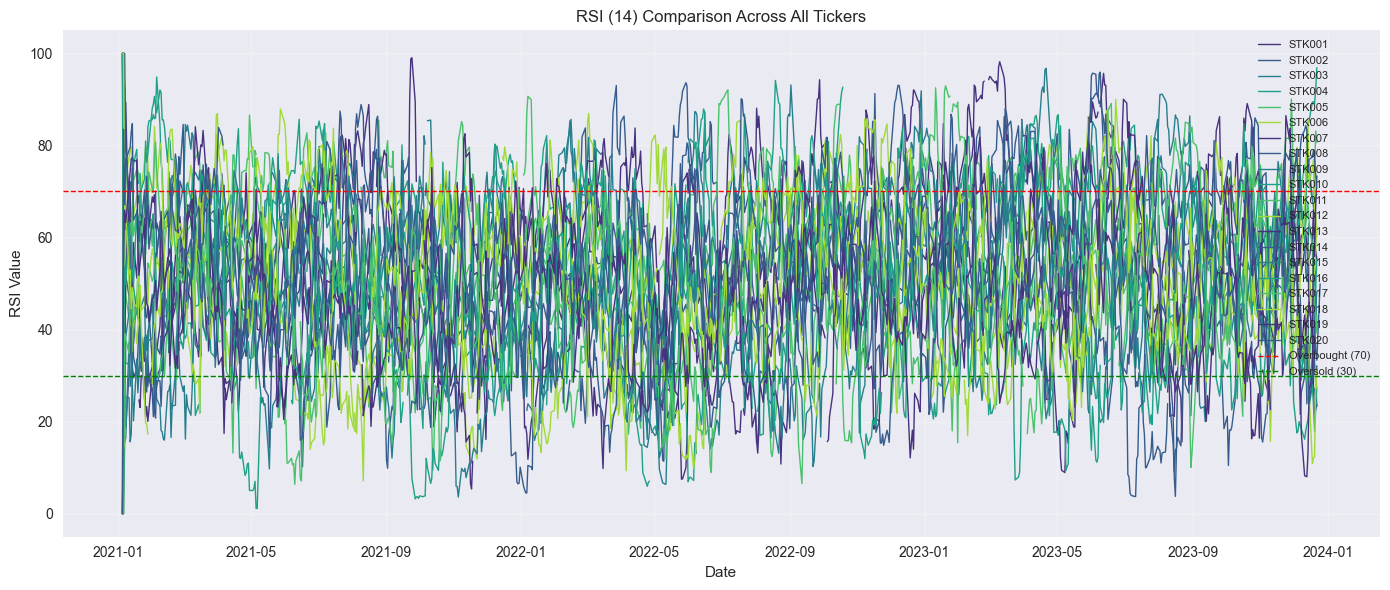

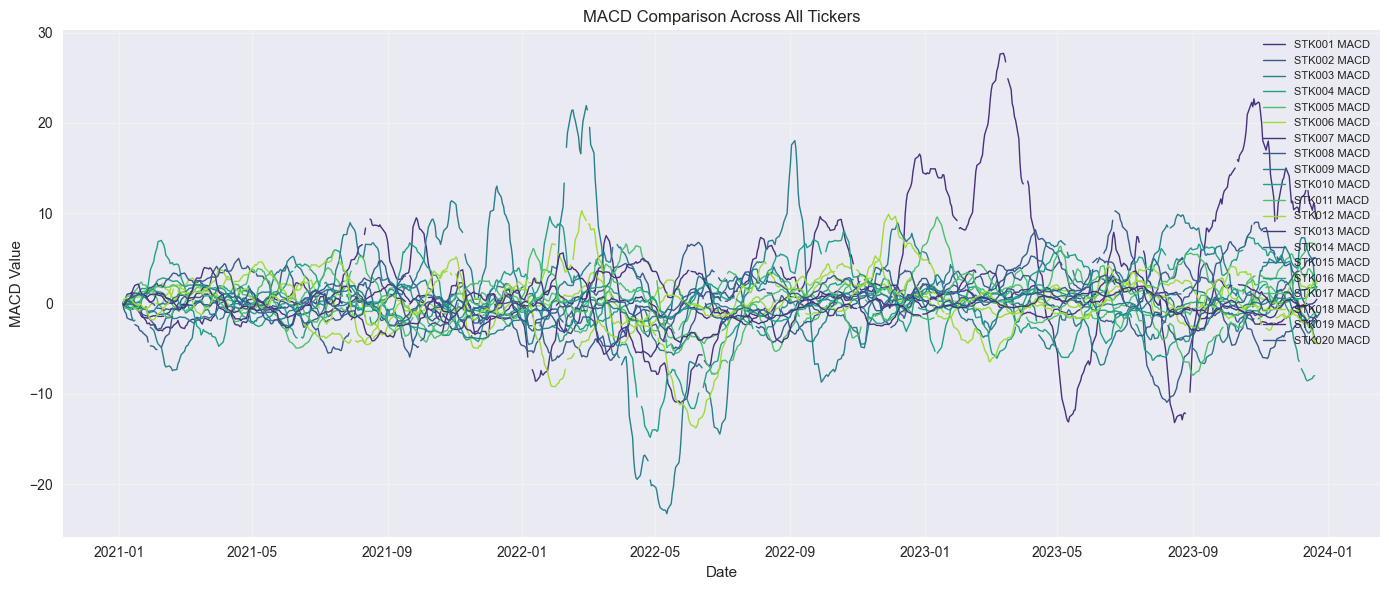

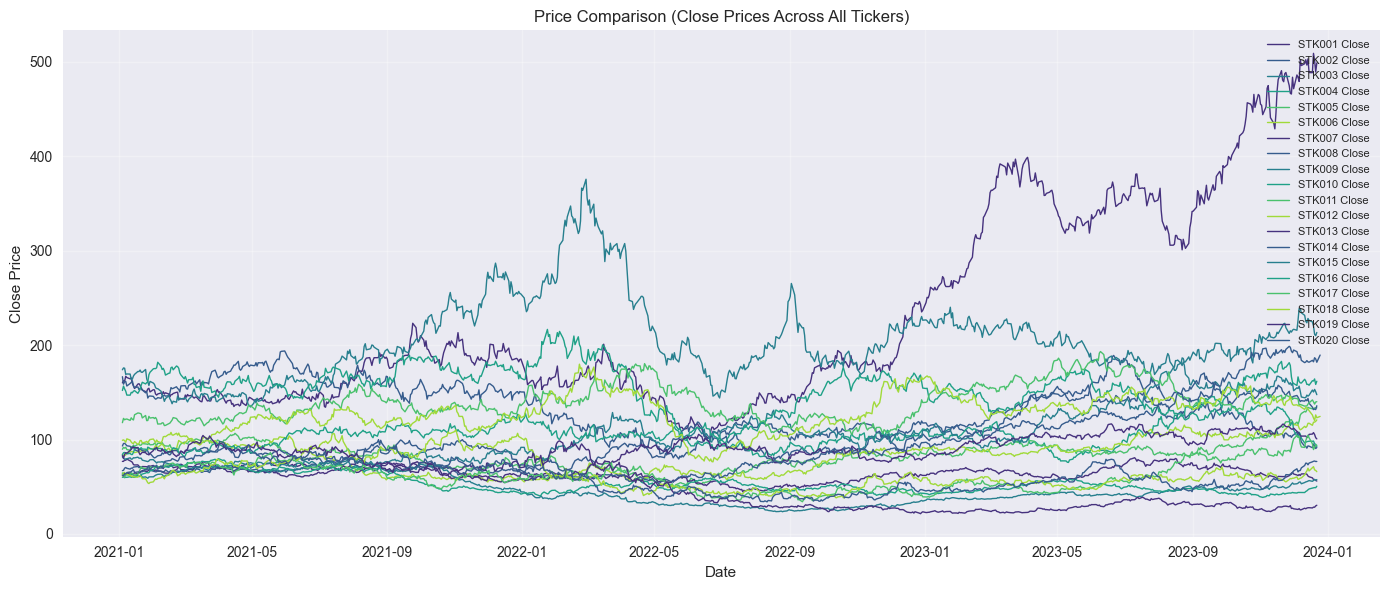

In [177]:
# Multi-Ticker Technical Analysis (All on Same Graphs)


# --- RSI Comparison Across All Tickers ---
plt.figure(figsize=(14, 6))
for ticker in company_info["ticker"].unique():
    df = stock_indicators[stock_indicators["ticker"] == ticker]
    plt.plot(df["date"], df["rsi_14"], label=ticker, linewidth=1)
plt.axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
plt.title("RSI (14) Comparison Across All Tickers")
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- MACD Comparison Across All Tickers ---
plt.figure(figsize=(14, 6))
for ticker in company_info["ticker"].unique():
    df = stock_indicators[stock_indicators["ticker"] == ticker]
    plt.plot(df["date"], df["macd"], label=f"{ticker} MACD", linewidth=1)
plt.title("MACD Comparison Across All Tickers")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- Bollinger Bands Comparison (Closes Only) ---
plt.figure(figsize=(14, 6))
for ticker in company_info["ticker"].unique():
    df = stock_indicators[stock_indicators["ticker"] == ticker]
    plt.plot(df["date"], df["close"], label=f"{ticker} Close", linewidth=1)
plt.title("Price Comparison (Close Prices Across All Tickers)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Correlation Analysis:

- Create correlation heatmap of selected features.
- Identify highly correlated features (potential multicollinearity)


In [187]:
# Select only numerical columns for correlation
num_features = stock_indicators.select_dtypes(include=['float64', 'int64'])

# --- Compute the correlation matrix ---
corr_matrix = num_features.corr()

corr_matrix

,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,ema_12,ema_26,macd,macd_signal,macd_histogram,rsi_14,bb_middle,bb_upper,bb_lower,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d
open,1.000000,0.999236,0.999225,0.998605,0.023873,0.998605,0.993388,0.979385,0.917216,0.997579,0.993283,0.333255,0.357454,-0.011759,0.113439,0.993381,0.990697,0.989364,0.723458,0.767611,0.938536,0.013732,-0.001306,0.098843,0.159060,0.220577,-0.059313,-0.014062
high,0.999236,1.000000,0.999504,0.999702,0.025145,0.999702,0.993018,0.978942,0.917095,0.997394,0.992953,0.335594,0.358119,-0.005489,0.120594,0.993008,0.990472,0.988816,0.724503,0.777606,0.939893,0.015688,0.001748,0.107560,0.165069,0.227080,-0.055595,-0.014466
low,0.999225,0.999504,1.000000,0.999706,0.021675,0.999706,0.992941,0.978714,0.916190,0.997346,0.992842,0.336563,0.359215,-0.005563,0.121443,0.992934,0.990066,0.989138,0.721418,0.758263,0.935882,0.010825,-0.004331,0.107922,0.165893,0.228313,-0.064697,-0.013847
close,0.998605,0.999702,0.999706,1.000000,0.023117,1.000000,0.992528,0.978328,0.916190,0.997019,0.992464,0.337332,0.359066,-0.002309,0.124682,0.992520,0.989827,0.988517,0.722685,0.767865,0.937334,0.013075,-0.001350,0.112215,0.168673,0.231205,-0.060542,-0.014240
volume,0.023873,0.025145,0.021675,0.023117,1.000000,0.023117,0.021275,0.019757,0.020777,0.022945,0.021758,0.025565,0.025118,0.006530,0.012145,0.021732,0.024559,0.018230,0.042104,0.100586,0.041294,0.130829,0.539463,0.003377,0.012267,0.006837,0.069098,-0.004265
adjusted_close,0.998605,0.999702,0.999706,1.000000,0.023117,1.000000,0.992528,0.978328,0.916190,0.997019,0.992464,0.337332,0.359066,-0.002309,0.124682,0.992520,0.989827,0.988517,0.722685,0.767865,0.937334,0.013075,-0.001350,0.112215,0.168673,0.231205,-0.060542,-0.014240
sma_20,0.993388,0.993018,0.992941,0.992528,0.021275,0.992528,1.000000,0.991843,0.930895,0.998604,0.999478,0.249354,0.296654,-0.107048,0.031244,1.000000,0.997224,0.996076,0.729055,0.764803,0.944741,0.018061,-0.002898,0.015918,0.077841,0.144904,-0.047896,-0.019135
sma_50,0.979385,0.978942,0.978714,0.978328,0.019757,0.978328,0.991843,1.000000,0.951634,0.987488,0.994676,0.141492,0.176082,-0.083037,-0.009602,0.991800,0.989774,0.987011,0.728417,0.755941,0.937729,0.019889,-0.002052,-0.011637,0.012834,0.055541,-0.038651,-0.023063
sma_200,0.917216,0.917095,0.916190,0.916190,0.020777,0.916190,0.930895,0.951634,1.000000,0.925910,0.937238,0.058133,0.068850,-0.019540,-0.028917,0.930961,0.930525,0.924654,0.697394,0.722369,0.897354,0.043486,-0.001089,-0.024869,-0.020941,-0.016261,0.022124,-0.022878
ema_12,0.997579,0.997394,0.997346,0.997019,0.022945,0.997019,0.998604,0.987488,0.925910,1.000000,0.998309,0.290932,0.327560,-0.062533,0.071404,0.998604,0.995854,0.994633,0.726865,0.767047,0.943635,0.016085,-0.001441,0.053679,0.118432,0.181212,-0.054737,-0.016374


##### Correlation Matrix:
Computes pairwise Pearson correlations between all numeric columns (like RSI, MACD, SMA, ATR, etc.).

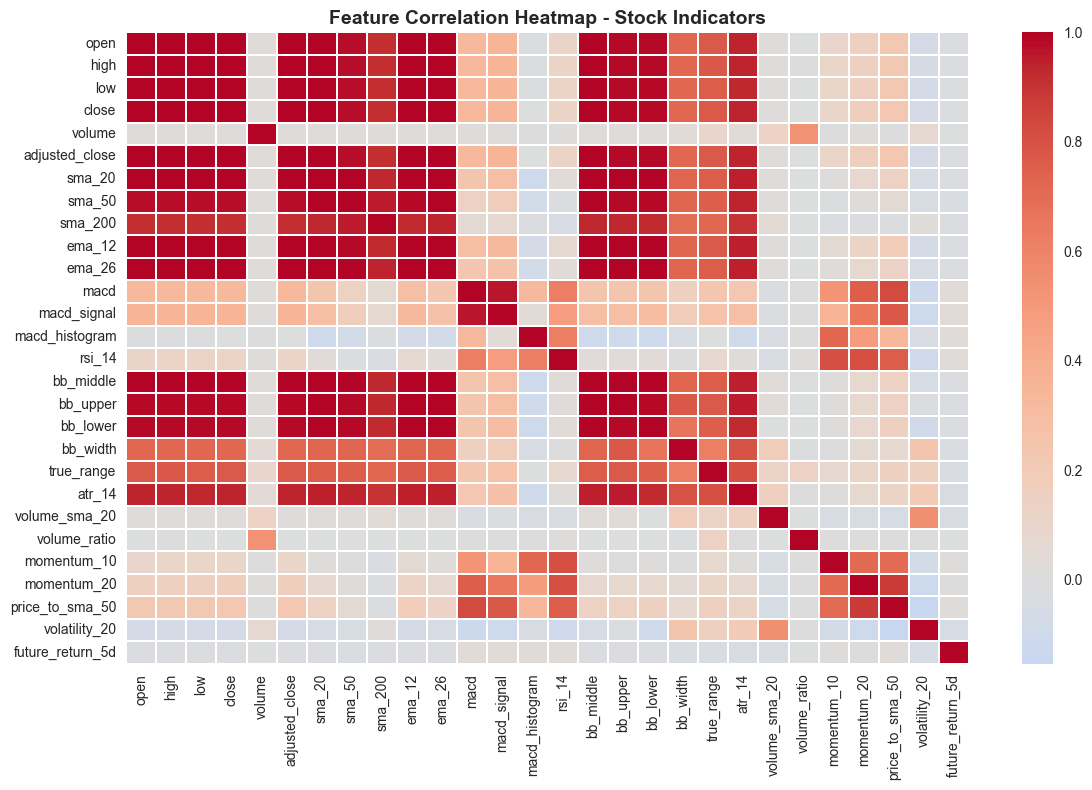

In [188]:
# --- Plot the correlation heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0, linewidths=0.3)
plt.title("Feature Correlation Heatmap - Stock Indicators", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

##### Heatmap:
red/orange = strong positive correlation, blue = strong negative.

bb_middle, bb_upper, bb_lower move almost identically.

In [190]:
# --- Identify highly correlated pairs ---
threshold = 0.85  # this can be adjusted
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Filter pairs above the threshold
high_corr = corr_pairs[abs(corr_pairs['Correlation']) > threshold].sort_values(
    by='Correlation', ascending=False
)

print("Highly Correlated Features (Potential Multicollinearity):")
high_corr

Highly Correlated Features (Potential Multicollinearity):


,Feature_1,Feature_2,Correlation
79,close,adjusted_close,1.000000
155,sma_20,bb_middle,1.000000
55,low,adjusted_close,0.999706
53,low,close,0.999706
30,high,adjusted_close,0.999702
...,...,...,...
58,low,sma_200,0.916190
82,close,sma_200,0.916190
127,adjusted_close,sma_200,0.916190
199,sma_200,atr_14,0.897354


##### High Correlation Detection:
The  above list shows feature pairs with correlation > 0.85.
These pairs indicate potential multicollinearity, which can distort regression models or feature importance in ML models.

### Day 5: Feature Selection & Data Preparation
Objective: Select relevant features and prepare clean dataset for modeling.

Tasks:
Feature Selection:

Review all 40+ features in stock_prices_with_indicators.csv.

Select 12-15 key features based on:
- Domain knowledge (which indicators are most important for trend prediction), 
- Correlation analysis (avoid highly correlated features), 
- Feature categories: momentum, trend, volatility, volume.


In [243]:
# Bollinger Bands calculated as: bb_upper, bb_lower, and close

stock_indicators['bb_position'] = (
    (stock_indicators['close'] - stock_indicators['bb_lower']) /
    (stock_indicators['bb_upper'] - stock_indicators['bb_lower'])
)

stock_indicators['bb_position']

0        0.323223
1        0.676777
2        0.577757
3        0.855317
4        0.697858
           ...   
15497    0.887732
15498    0.877414
15499    0.857767
15500    0.812438
15501    0.787362
Name: bb_position, Length: 15502, dtype: float64

stochastic_k — Fast %K Oscillator

Concept:
This measures where the closing price is within a recent high-low range — capturing short-term momentum.

Formula:

stochastic_k =100×Close−Lowest Low (n)/
Highest High (n)
−
Lowest Low (n)



Typically, n = 14 periods.

In [282]:
n = 14

stock_indicators['stochastic_k'] = (
    (stock_indicators['close'] - stock_indicators['low'].rolling(n).min()) /
    (stock_indicators['high'].rolling(n).max() - stock_indicators['low'].rolling(n).min())
) * 100


In [297]:
stock_prices.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close,daily_return,high_volume,obv_change,obv
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644,160.11,NaN,False,NaN,0.0
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36,0.014053,False,1.0,1312685.0


In [298]:
stock_indicators.head()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,ema_12,ema_26,macd,macd_signal,macd_histogram,rsi_14,bb_middle,bb_upper,bb_lower,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label,bb_position,stochastic_k,obv_x,obv_y,obv
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,160.110000,160.110000,160.110000,0.000000,0.000000,0.000000,100.000000,160.110000,164.416981,158.053019,6.363961,2.88,2.880,962644.00,1.000000,-0.008557,-0.045594,0.000000,0.012463,0.026357,Uptrend,0.323223,NaN,0.0,0.0,0.0
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,161.235000,160.456154,160.276667,0.179487,0.035897,0.143590,100.000000,161.235000,164.416981,158.053019,6.363961,5.39,4.135,1137664.50,1.153842,-0.008557,-0.045594,0.006977,0.012463,0.018169,Sideways,0.676777,NaN,1312685.0,1312685.0,1312685.0
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,161.416667,160.659822,160.388025,0.271798,0.083078,0.188720,79.505300,161.416667,163.753017,159.080316,4.672701,1.57,3.280,1241502.00,1.167277,-0.008557,-0.045594,0.002251,0.012463,-0.012301,Sideways,0.577757,NaN,-136492.0,-136492.0,-136492.0
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,162.830000,161.646004,160.882986,0.763018,0.219066,0.543952,92.857143,162.830000,168.796507,156.863493,11.933013,6.12,3.990,1314834.75,1.167320,-0.008557,-0.045594,0.026039,0.018138,-0.061950,Downtrend,0.855317,NaN,1398341.0,1398341.0,1398341.0
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,163.400000,162.266618,161.238320,1.028298,0.380912,0.647386,79.284963,163.400000,169.161718,157.638282,11.523437,4.08,4.008,1221520.00,0.694431,-0.008557,-0.045594,0.013953,0.018663,-0.070196,Downtrend,0.697858,NaN,550080.0,550080.0,550080.0


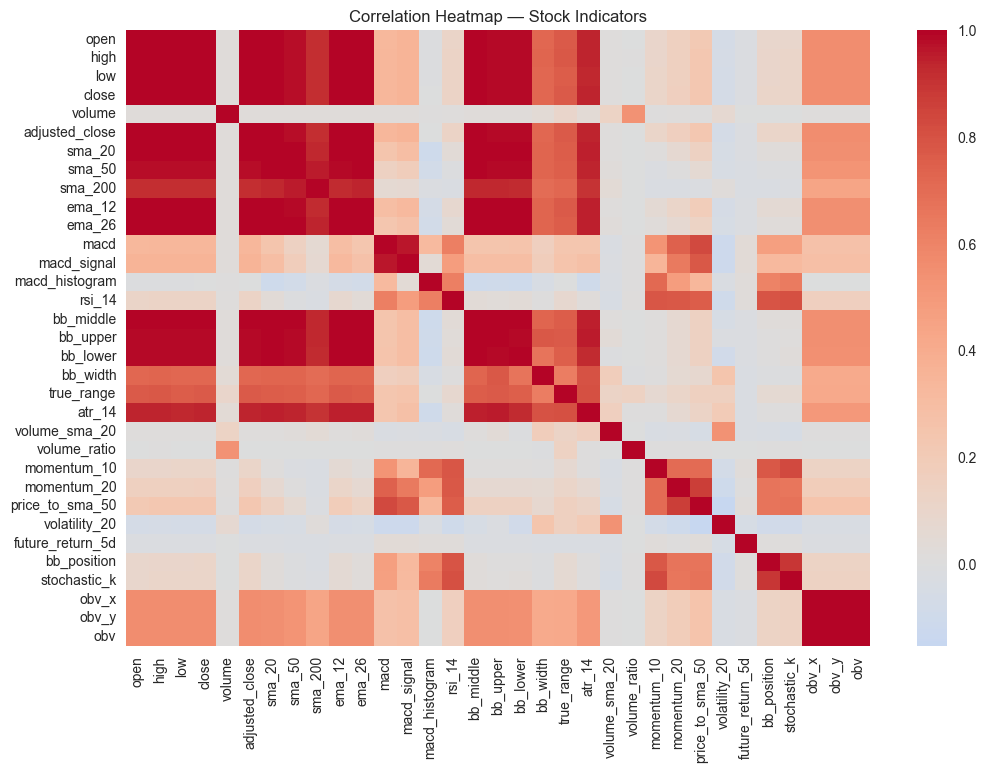

In [299]:
# Check for Redundancy / Correlation - compute a correlation matrix to detect highly correlated features:

corr = stock_indicators.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Stock Indicators")
plt.show()

open, high, low, close, smas and bbs are highly correlated

In [300]:
selected_features = [
    'momentum_10', 'momentum_20', 
    'sma_20', 'sma_50', 'price_to_sma_50',
    'rsi_14', 'macd', 'macd_signal',
    'atr_14', 'volatility_20', 'bb_width',
    'volume_ratio', 'obv',
    'bb_position', 'stochastic_k',
    'trend_label']

stock_features = stock_indicators[selected_features].copy()

stock_features.head(2)

,momentum_10,momentum_20,sma_20,sma_50,price_to_sma_50,rsi_14,macd,macd_signal,atr_14,volatility_20,bb_width,volume_ratio,obv,bb_position,stochastic_k,trend_label
0,-0.008557,-0.045594,160.110,160.110,0.000000,100.0,0.000000,0.000000,2.880,0.012463,6.363961,1.000000,0.0,0.323223,NaN,Uptrend
1,-0.008557,-0.045594,161.235,161.235,0.006977,100.0,0.179487,0.035897,4.135,0.012463,6.363961,1.153842,1312685.0,0.676777,NaN,Sideways


In [301]:
# Drop Highly Correlated Features Automatically

# Threshold for dropping correlated features
threshold = 0.9

# Create correlation matrix
corr_matrix = numeric_cols.corr().abs()

# Keep only the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation above threshold
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features (to drop):")
print(to_drop)



Highly correlated features (to drop):
['high', 'low', 'close', 'adjusted_close', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd_signal', 'bb_middle', 'bb_upper', 'bb_lower', 'atr_14']


In [302]:
stock_uncorr = stock_indicators.drop(columns=to_drop)
print("Reduced feature set:", stock_uncorr.shape)

Reduced feature set: (15502, 22)


In [303]:
stock_uncorr.head(2)

,ticker,date,open,volume,macd,macd_histogram,rsi_14,bb_width,true_range,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label,bb_position,stochastic_k,obv_x,obv_y,obv
0,STK001,2021-01-04,158.09,962644.0,0.000000,0.00000,100.0,6.363961,2.88,962644.0,1.000000,-0.008557,-0.045594,0.000000,0.012463,0.026357,Uptrend,0.323223,NaN,0.0,0.0,0.0
1,STK001,2021-01-05,163.16,1312685.0,0.179487,0.14359,100.0,6.363961,5.39,1137664.5,1.153842,-0.008557,-0.045594,0.006977,0.012463,0.018169,Sideways,0.676777,NaN,1312685.0,1312685.0,1312685.0


In [304]:
# Handle Missing Values in stock_indicators

# Forward fill, then backward fill
stock_indicators = stock_indicators.fillna(method='ffill')
stock_indicators = stock_indicators.fillna(method='bfill')

# Verify remaining missing values
print("Remaining NaNs after filling:")
print(stock_indicators.isna().sum().sum())

Remaining NaNs after filling:
0


/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/418045616.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_indicators = stock_indicators.fillna(method='ffill')
/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/418045616.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_indicators = stock_indicators.fillna(method='bfill')


In [305]:

# Include essential columns for reference
modeling_df = stock_indicators[['ticker', 'date', 'trend_label'] + selected_features].copy()

# Drop rows without target label
modeling_df = modeling_df.dropna(subset=['trend_label'])

# Verify no missing targets remain
print("Missing targets after cleanup:", modeling_df['trend_label'].isna().sum())


Missing targets after cleanup: trend_label    0
trend_label    0
dtype: int64


In [306]:
# Ensure No Data Leakage

if 'future_return_5d' in modeling_df.columns:
    modeling_df = modeling_df.drop(columns=['future_return_5d'])


In [307]:
# Remove duplicate columns, keeping the first occurrence
modeling_df = modeling_df.loc[:, ~modeling_df.columns.duplicated()]


In [308]:
# Temporal Train-Test Split (Since it’s time-series data, we do not shuffle, We’ll split based on date order.)

# Ensure date is in datetime format
modeling_df['date'] = pd.to_datetime(modeling_df['date'])

# Sort by ticker and date
modeling_df = modeling_df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Find split index (70% train, 30% test)
split_index = int(len(modeling_df) * 0.7)

train_df = modeling_df.iloc[:split_index]
test_df  = modeling_df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train end date:", train_df['date'].max())
print("Test start date:", test_df['date'].min())

Train shape: (10851, 18)
Test shape: (4651, 18)
Train end date: 2023-12-25 00:00:00
Test start date: 2021-01-04 00:00:00


/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/3444308089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modeling_df['date'] = pd.to_datetime(modeling_df['date'])


In [309]:
print("\n--- Data Overview ---")
print(f"Total samples: {len(modeling_df)}")
print(f"Training samples: {len(train_df)} ({len(train_df)/len(modeling_df)*100:.1f}%)")
print(f"Testing samples:  {len(test_df)} ({len(test_df)/len(modeling_df)*100:.1f}%)")
print("\nFeature count:", len(selected_features))



--- Data Overview ---
Total samples: 15502
Training samples: 10851 (70.0%)
Testing samples:  4651 (30.0%)

Feature count: 16


#### Feature Documentation and Justification

The selected 14 features represent a balanced mix of price momentum, trend strength, volatility, and volume dynamics, each providing complementary insights into stock behavior and market regimes. These features were chosen based on both domain knowledge and correlation analysis to avoid redundancy while retaining interpretability and predictive power.

Price Momentum:
The features momentum_10 and momentum_20 capture short- and medium-term price velocity. They measure how much the price has changed over the last 10 or 20 trading periods. These indicators are valuable because strong positive or negative momentum often precedes trend continuation or reversal, helping the model identify uptrends or downtrends early.

Moving Averages:
sma_20 and sma_50 represent the 20-day and 50-day simple moving averages, capturing short- and mid-term price trends. price_to_sma_50 expresses the ratio of the current price to its 50-day average, providing a normalized measure of how extended or compressed prices are relative to their mean trend. Together, these features capture both the direction and relative strength of price movements, making them foundational to trend classification.

Momentum Indicators:
rsi_14 (Relative Strength Index) quantifies recent price gains versus losses to assess overbought or oversold conditions. macd (Moving Average Convergence Divergence) and macd_signal measure the difference and smoothing of two exponential moving averages, effectively tracking the shift between bullish and bearish momentum phases. These momentum-based features complement moving averages by introducing sensitivity to market acceleration and deceleration.

Volatility Measures:
atr_14 (Average True Range) reflects average daily price range over 14 periods, capturing the magnitude of price fluctuations. volatility_20 represents statistical price variability over 20 days, while bb_width (Bollinger Band Width) measures the spread between upper and lower Bollinger Bands. Collectively, these features describe how turbulent or stable price behavior is—critical for differentiating sideways markets from trending ones.

Volume Indicators:
volume_ratio compares recent trading volume to historical averages, identifying abnormal spikes or contractions in market activity. obv (On-Balance Volume) combines price and volume changes to measure buying and selling pressure. Volume dynamics provide context for trend validation: a trend supported by strong volume tends to be more reliable.

Position Indicators:
bb_position measures where the current price lies within the Bollinger Bands (e.g., near upper, middle, or lower bounds), and stochastic_k captures the price’s position relative to its recent range. Both features highlight the relative placement of price within its short-term context—useful for identifying potential reversals or consolidation zones.

Overall Justification:
These 14 features jointly provide a comprehensive, non-redundant view of the market from multiple angles: direction, speed, volatility, and participation. They balance short-term sensitivity with longer-term stability, making them well-suited for models aimed at detecting uptrend, downtrend, or sideways regimes with high interpretability and reduced overfitting risk.

In [310]:
# Select key features + target variable
selected_features = [
    'momentum_10', 'momentum_20', 
    'sma_20', 'sma_50', 'price_to_sma_50',
    'rsi_14', 'macd', 'macd_signal',
    'atr_14', 'volatility_20', 'bb_width',
    'volume_ratio', 'obv',
    'bb_position', 'stochastic_k',
    'trend_label'
]

# Filter to selected columns
modeling_df = stock_indicators[selected_features + ['ticker', 'date']].copy()

# Handle missing values
modeling_df = modeling_df.sort_values(['ticker', 'date'])
modeling_df = modeling_df.fillna(method='ffill').fillna(method='bfill')

# Drop rows with missing target
modeling_df = modeling_df.dropna(subset=['trend_label'])

# Save to CSV
modeling_df.to_csv("../data/modeling_dataset.csv", index=False)

print("✅ Clean dataset saved as modeling_dataset.csv")
print(f"Shape: {modeling_df.shape}")


/var/folders/44/k4r0trmx3jl_w9vvtcfvf3qh0000gn/T/ipykernel_90185/1797916731.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  modeling_df = modeling_df.fillna(method='ffill').fillna(method='bfill')


✅ Clean dataset saved as modeling_dataset.csv
Shape: (15502, 18)
